# Proyek Analisis Data: Bike sharing
- **Nama:** Raufa Ummuhani
- **Email:** raufaummuhani@gmail.com
- **ID Dicoding:** ms192d5x0633

## Menentukan Pertanyaan Bisnis

1. Apakah ada perbedaan signifikan dalam penggunaan sepeda di setiap musim?
2. Bagaimana penggunaan sepeda lebih tinggi pada hari kerja tertentu (weekday)?


## Import Semua Packages/Library yang Digunakan

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded = files.upload()



Saving day.csv to day.csv


Saving hour.csv to hour.csv


In [ ]:
import pandas as pd
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')
day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset terdiri dari dua bagian, yaitu "day.csv" untuk data harian dan "hour.csv" untuk data per jam. Keduanya memiliki kolom terkait tanggal, cuaca, dan jumlah pengguna sepeda.


### Assessing Data

In [ ]:
day_df.info()
hour_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [ ]:
print(day_df.dtypes) # Melihat tipe data
day_df['dteday'] = pd.to_datetime(day_df['dteday'])  # Mengubah ke format datetime


dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [ ]:
day_df.drop(columns=['instant'], inplace=True)  # menghapus ID yang tidak berguna
hour_df.drop(columns=['instant'], inplace=True) # menghapus ID yang tidak berguna


In [ ]:
day_df[day_df['hum'] == 0]  # Menampilkan baris dengan kelembaban 0



**Insight:**
- Kolom instant dihapus karena hanya berupa nomor indeks yang tidak memiliki makna analitis. Data sudah memiliki kolom tanggal (dteday) yang bisa digunakan untuk analisis berbasis waktu, sehingga instant tidak memberikan informasi tambahan.
- kelembapan harus lebih dari 0

### Cleaning Data

In [ ]:
day_df.loc[day_df['hum'] == 0, 'hum'] = day_df['hum'].median() # Menghapus hum yang tidak sesuai (0)


**Insight:**
- menghapus hum yang bernilai 0


## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



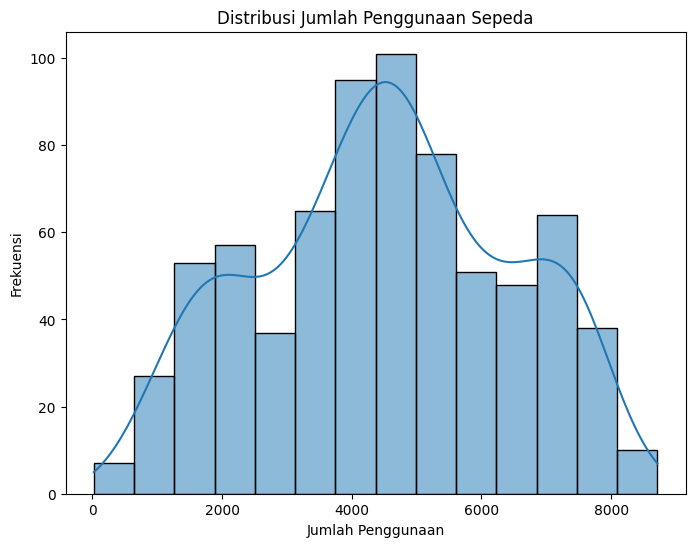

In [ ]:
# a. Distribusi Data Numerik
plt.figure(figsize=(8, 6))
sns.histplot(df['cnt'], kde=True)
plt.title('Distribusi Jumlah Penggunaan Sepeda')
plt.xlabel('Jumlah Penggunaan')
plt.ylabel('Frekuensi')
plt.show()


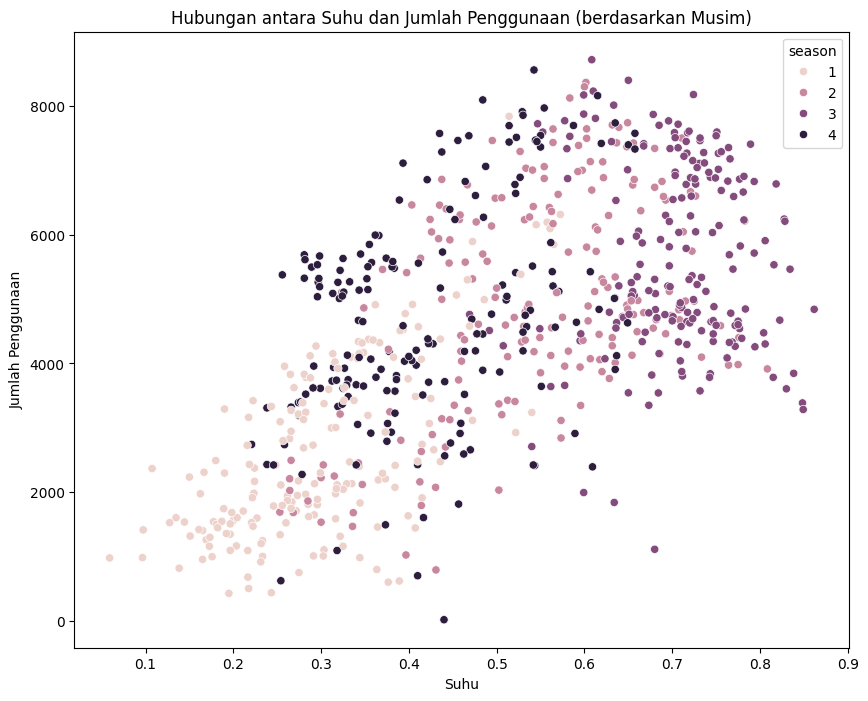

In [7]:
# Plot hubungan antara suhu dan jumlah penggunaan berdasarkan musim
plt.figure(figsize=(10, 8))
sns.scatterplot(x='temp', y='cnt', data=df, hue='season')
plt.title('Hubungan antara Suhu dan Jumlah Penggunaan (berdasarkan Musim)')
plt.xlabel('Suhu')
plt.ylabel('Jumlah Penggunaan')
plt.show()


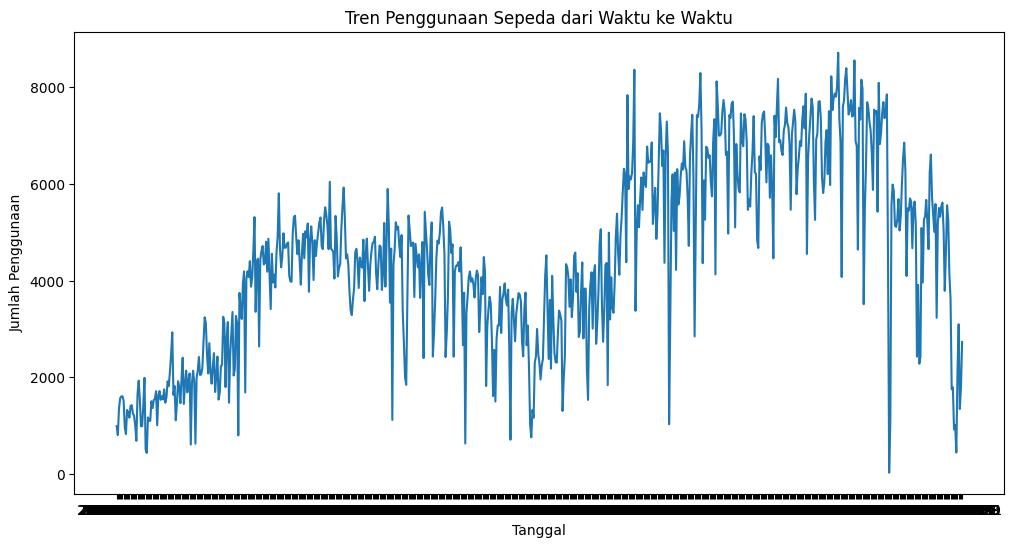

In [ ]:
# c. Tren Waktu
plt.figure(figsize=(12, 6))
plt.plot(df['dteday'], df['cnt'])
plt.title('Tren Penggunaan Sepeda dari Waktu ke Waktu')
plt.xlabel('Tanggal')
plt.ylabel('rata rata penggunaan')
plt.show()

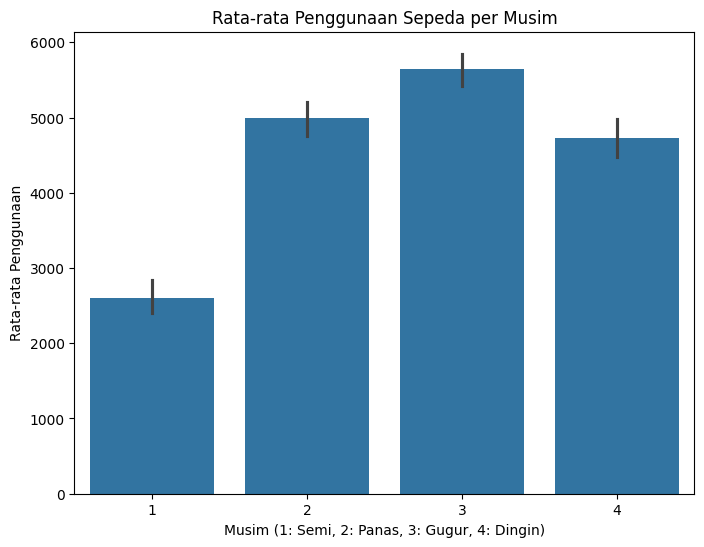

In [ ]:
# d. Penggunaan Berdasarkan Musim
plt.figure(figsize=(8, 6))
sns.barplot(x='season', y='cnt', data=df)
plt.title('Rata-rata Penggunaan Sepeda per Musim')
plt.xlabel('Musim (1: Semi, 2: Panas, 3: Gugur, 4: Dingin)')
plt.ylabel('Rata-rata Penggunaan')
plt.show()

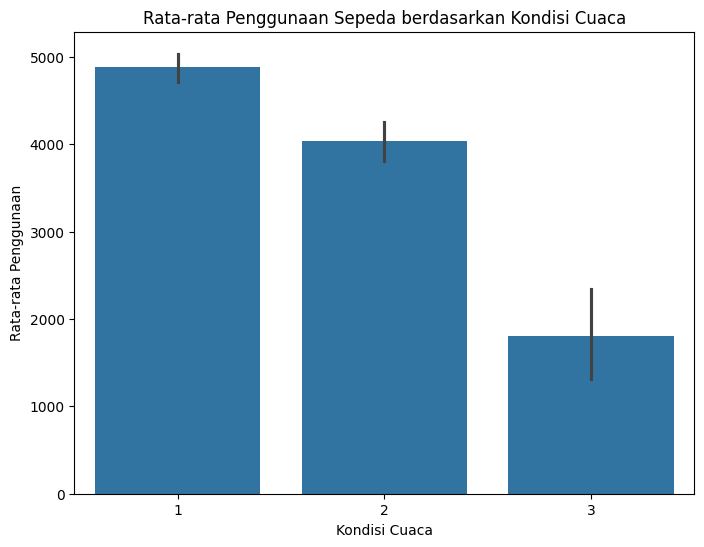

In [ ]:
# e. Penggunaan Berdasarkan Kondisi Cuaca
plt.figure(figsize=(8, 6))
sns.barplot(x='weathersit', y='cnt', data=df)
plt.title('Rata-rata Penggunaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penggunaan')
plt.show()


Korelasi antara Suhu dan Jumlah Penggunaan: 0.6274940090334918


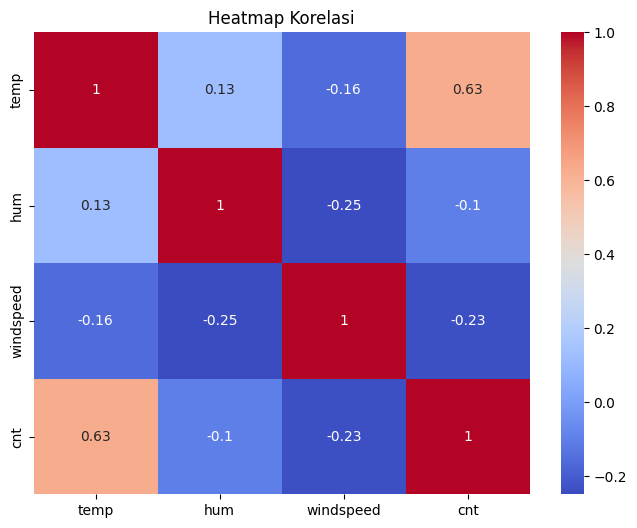

In [ ]:
### Korelasi Antar Variabel
correlation = df['temp'].corr(df['cnt'])
print(f"\nKorelasi antara Suhu dan Jumlah Penggunaan: {correlation}")

correlation_matrix = df[['temp', 'hum', 'windspeed', 'cnt']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

**Insight:**
-  Distribusi penggunaan sepeda menunjukksn pola tertentu, apakah ada kecenderungan penggunaan tinggi atau rendah.
- Boxplot suhu membantu mengidentifikasi outlier atau variasi suhu yang signifikan.
- Hubungan suhu dengan jumlah penggunaan sepeda dapat mengindikasikan bagaimana cuaca memengaruhi aktivitas bersepeda.
- Tren waktu menunjukkan pola musiman atau tren jangka panjang dalam penggunaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Apakah ada perbedaan signifikan dalam penggunaan sepeda di setiap musim?


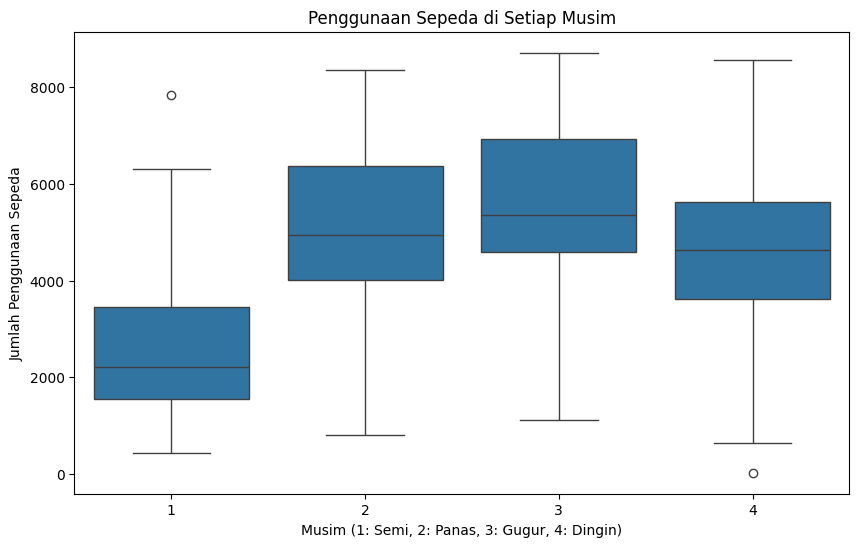

In [ ]:
# Visualisasi 1: Perbedaan penggunaan sepeda di setiap musim
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='cnt', data=day)
plt.title('Penggunaan Sepeda di Setiap Musim')
plt.xlabel('Musim (1: Semi, 2: Panas, 3: Gugur, 4: Dingin)')
plt.ylabel('Jumlah Penggunaan Sepeda')
plt.show()


### Pertanyaan 2:
Apakah penggunaan sepeda lebih tinggi pada hari kerja tertentu (weekday)?


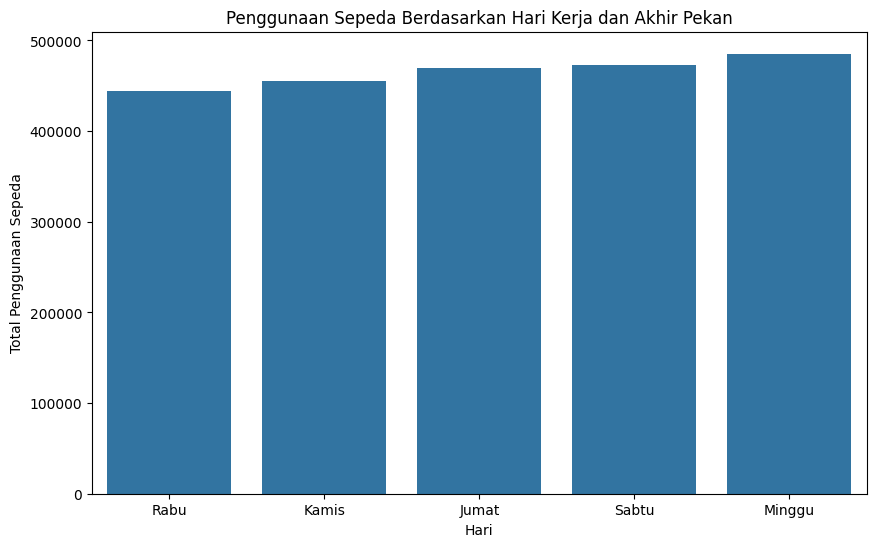

In [ ]:
weekday_mapping = {0: 'Senin', 1: 'Selasa', 2: 'Rabu', 3: 'Kamis', 4: 'Jumat', 5: 'Sabtu', 6: 'Minggu'}
day['weekday_name'] = day['weekday'].map(weekday_mapping)

plt.figure(figsize=(10, 6))
sns.barplot(x='weekday_name', y='cnt', data=day, estimator=sum, errorbar=None)
plt.title('Penggunaan Sepeda Berdasarkan Hari Kerja dan Akhir Pekan')
plt.xlabel('Hari')
plt.ylabel('Total Penggunaan Sepeda')
plt.show()


## Analisis Lanjutan (Opsional)

## Conclusion

1. Apakah ada perbedaan signifikan dalam penggunaan sepeda di setiap musim?
   Ada perbedaan signifikan dalam penggunaan sepeda di setiap musim. Penggunaan sepeda lebih rendah di musim dingin dan meningkat pada musim yang lebih hangat.

2. Apakah penggunaan sepeda lebih tinggi pada hari kerja(weekday)?
   Penggunaan sepeda tidak jauh berbeda antara hari kerja dan akhir pekan. Tidak ada satu hari kerja tertentu yang secara signifikan lebih tinggi dibandingkan hari lainnya.


